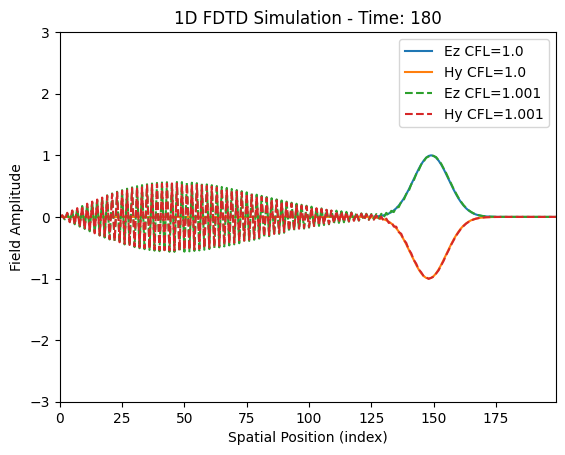

In [1]:
import numpy as np
import matplotlib.pyplot as plt

SIZE = 200
maxTime = 300
imp0 = 377.0

ez = np.zeros(SIZE)
hy = np.zeros(SIZE)
ez_high = np.zeros(SIZE)
hy_high = np.zeros(SIZE)

cfl_low = 1.000
cfl_high = 1.001

def update_fields(ez, hy, cfl):
    hy[:-1] += cfl * (ez[1:] - ez[:-1]) / imp0
    ez[1:] += cfl * (hy[1:] - hy[:-1]) * imp0
    return ez, hy

target_time = int(maxTime * 0.6)

for qTime in range(target_time):
    ez, hy = update_fields(ez, hy, cfl_low)
    ez[0] = np.exp(-((qTime - 30.0) ** 2) / 100.0)

    ez_high, hy_high = update_fields(ez_high, hy_high, cfl_high)
    ez_high[0] = np.exp(-((qTime - 30.0) ** 2) / 100.0)

fig, ax = plt.subplots()
ax.plot(ez,              label="Ez CFL=1.0")
ax.plot(hy * imp0,       label="Hy CFL=1.0")
ax.plot(ez_high,         label="Ez CFL=1.001", linestyle="--")
ax.plot(hy_high * imp0,  label="Hy CFL=1.001", linestyle="--")

ax.set_ylim(-3, 3)
ax.set_xlim(0, SIZE - 1)
ax.set_xlabel("Spatial Position (index)")
ax.set_ylabel("Field Amplitude")
ax.set_title(f"1D FDTD Simulation - Time: {target_time}")
ax.legend(loc="upper right", fontsize=10, frameon=True)
plt.show()
